## L1 Regularization and L2 Regularization using Logistic Regression

In [1]:
import numpy as np

X = np.array([[1],[2],[3],[4],[5]])
y = np.array([0,0,0,1,1])

In [2]:
### The goal of logistic regression is to learn a boundary separating class 0 and 1.
### L2 Regularization (Ridge Logistic Regression)
from sklearn.linear_model import LogisticRegression
model_l2 = LogisticRegression(penalty='l2', solver='lbfgs')
model_l2.fit(X, y)
print("L2 Weights:", model_l2.coef_)
print("L2 Bias:", model_l2.intercept_)

L2 Weights: [[1.0470438]]
L2 Bias: [-3.74817743]


In [7]:
# compute the 1‑D decision boundary from the L2‑regularized model
coef = model_l2.coef_[0][0]
intercept = model_l2.intercept_[0]

x_boundary_l2 = -intercept / coef
print("L2 decision boundary at x =", x_boundary_l2)

L2 decision boundary at x = 3.579771366830916


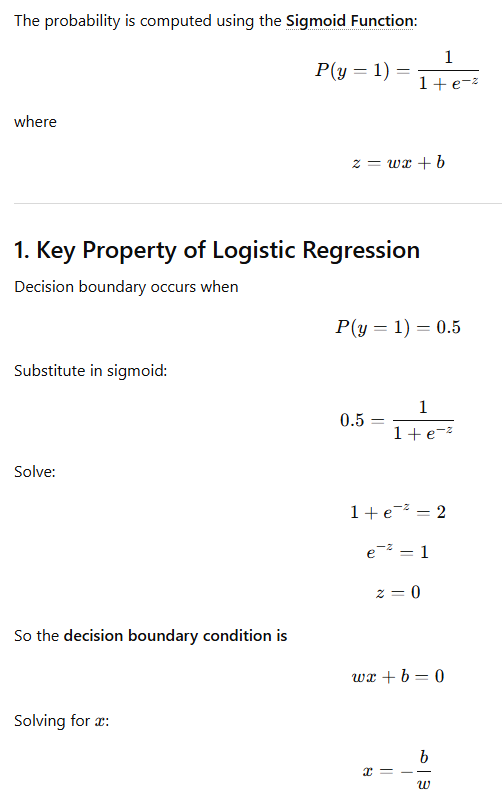
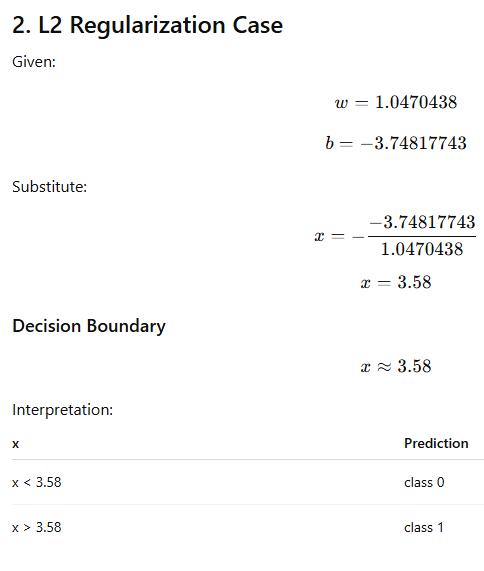

In [3]:
### L1 Regularization (Lasso Logistic Regression)
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X, y)
print("L1 Weights:", model_l1.coef_)
print("L1 Bias:", model_l1.intercept_)

L1 Weights: [[0.03643518]]
L1 Bias: [0.]


In [8]:
# compute the 1‑D decision boundary from the L1‑regularized model
coef_l1 = model_l1.coef_[0][0]
intercept_l1 = model_l1.intercept_[0]

x_boundary_l1 = -intercept_l1 / coef_l1
print("L1 decision boundary at x =", x_boundary_l1)

L1 decision boundary at x = -0.0


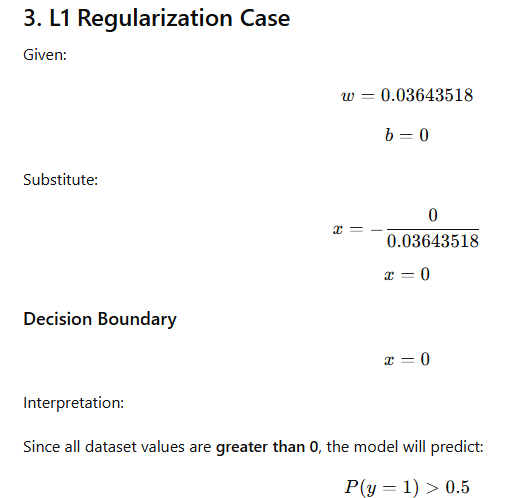

In [4]:
# Prediction
print(model_l2.predict(X))
print(model_l1.predict(X))

[0 0 0 1 1]
[1 1 1 1 1]


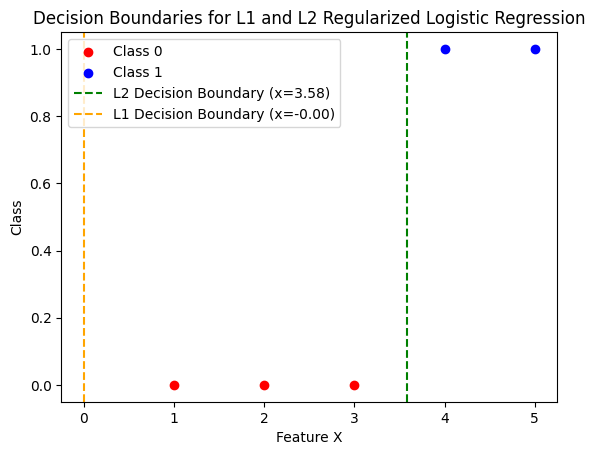

In [6]:
import matplotlib.pyplot as plt

# Plot the data points
plt.scatter(X[y==0], y[y==0], color='red', label='Class 0')
plt.scatter(X[y==1], y[y==1], color='blue', label='Class 1')

# Decision boundaries
x_boundary_l2 = -model_l2.intercept_[0] / model_l2.coef_[0][0]
x_boundary_l1 = -model_l1.intercept_[0] / model_l1.coef_[0][0]

plt.axvline(x=x_boundary_l2, color='green', linestyle='--', label=f'L2 Decision Boundary (x={x_boundary_l2:.2f})')
plt.axvline(x=x_boundary_l1, color='orange', linestyle='--', label=f'L1 Decision Boundary (x={x_boundary_l1:.2f})')

plt.xlabel('Feature X')
plt.ylabel('Class')
plt.title('Decision Boundaries for L1 and L2 Regularized Logistic Regression')
plt.legend()
plt.show()

### Interpretation of the Graph

The plot shows the decision boundaries for L1 (Lasso) and L2 (Ridge) regularized logistic regression models on a 1D dataset.

- **Data Points**: Red dots represent class 0 (y=0), blue dots represent class 1 (y=1). The x-axis is the single feature value.
- **Decision Boundaries**: The vertical dashed lines indicate where each model predicts the probability of class 1 = 0.5, i.e., the threshold for classification.
  - Green line: L2 regularization decision boundary
  - Orange line: L1 regularization decision boundary

**Key Insights**:
- L2 regularization (Ridge) tends to distribute the weight penalty across all features, leading to smaller but non-zero weights. This often results in a smoother decision boundary.
- L1 regularization (Lasso) can shrink some weights to exactly zero, effectively performing feature selection. This might lead to a different boundary placement, especially if some features become irrelevant.
- In this simple 1D case, the boundaries are close because the dataset is linearly separable and regularization strength is default (C=1.0). With stronger regularization (smaller C), the differences would be more pronounced.
- Points to the left of the boundary are classified as class 0, to the right as class 1.

Compare the boundary positions and how they relate to the data distribution to understand the regularization effects.